In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt


* X` is the preprocessed input data of shape (3492, 50, 8)
* corresponding asset returns `R` of shape (3492, 4)

* Each row contains [r_stock, r_bond, r_commodity, r_volatility]

In [2]:
X = np.load('X_data.npy')
R = np.load('Y_data.npy')

In [3]:
assert X.shape[0] == R.shape[0]


In [4]:
n_assets = R.shape[1]
lookback = X.shape[1]

### Model definition

In [5]:
class SharpeModel(tf.keras.Model):
    def __init__(self, n_assets):
        super().__init__()
        self.lstm = tf.keras.layers.LSTM(64)
        self.dense = tf.keras.layers.Dense(n_assets)

    def call(self, x):
        x = self.lstm(x)
        raw_weights = self.dense(x)
        weights = tf.nn.softmax(raw_weights)  # Eq. (5)
        return weights



* Custom Loss Function (Eq. 1-6)

    * R: returns = the actual returns of each asset for a given time step t
    
    * W: weights = predicted portfolio weights from the model

In [6]:
def sharpe_loss(R, W):
    R = tf.cast(R, tf.float32)
    W = tf.cast(W, tf.float32)
    portfolio_returns = tf.reduce_sum(R * W, axis=1)
    mean = tf.reduce_mean(portfolio_returns)
    std = tf.math.reduce_std(portfolio_returns)
    sharpe = mean / (std + 1e-8)
    return -sharpe


### Training the model

In [7]:
def train_model_sharpe(X, R, train_end_index, epochs=100):
    print(f"\nTraining on samples 0 to {train_end_index - 1}")

    model = SharpeModel(n_assets)
    optimizer = tf.keras.optimizers.Adam(1e-3)

    # Split 90% train / 10% validation
    val_split = int(train_end_index * 0.9)
    X_train, R_train = X[:val_split], R[:val_split]
    X_val, R_val = X[val_split:train_end_index], R[val_split:train_end_index]

    train_dataset = tf.data.Dataset.from_tensor_slices((X_train, R_train)).batch(64)
    val_dataset = tf.data.Dataset.from_tensor_slices((X_val, R_val)).batch(64)

    for epoch in range(epochs):
        for x_batch, r_batch in train_dataset:
            with tf.GradientTape() as tape:
                weights = model(x_batch)
                loss = sharpe_loss(r_batch, weights)
            grads = tape.gradient(loss, model.trainable_variables)
            optimizer.apply_gradients(zip(grads, model.trainable_variables))

        val_losses = []
        for x_val, r_val in val_dataset:
            val_weights = model(x_val)
            val_loss = sharpe_loss(r_val, val_weights)
            val_losses.append(val_loss.numpy())
        avg_val_loss = np.mean(val_losses)
        print(f"Epoch {epoch + 1}/{epochs} - Validation Sharpe Loss: {-avg_val_loss:.4f}")

    return model

### Volatility estimate and backtest

In [8]:
def exponential_weighted_volatility(returns, span=50):
    alpha = 2 / (span + 1)
    ewma = [returns[0]]
    for r in returns[1:]:
        ewma.append(alpha * r + (1 - alpha) * ewma[-1])
    ewma = np.array(ewma)
    squared_diff = (returns - ewma) ** 2
    ew_var = np.convolve(squared_diff, np.exp(-np.arange(span)[::-1] * alpha), mode='valid')
    ew_std = np.sqrt(ew_var)
    return np.pad(ew_std, (span - 1, 0), constant_values=np.nan)

In [9]:
def backtest(X, R, model, cost_rate=0.0001, vol_target=0.10):
    T = len(X)
    returns = []
    weights = []
    prev_scaled = np.zeros(R.shape[1])
    vol_est = np.array([exponential_weighted_volatility(R[:, i]) for i in range(R.shape[1])]).T

    for t in range(2, T):
        sigma = vol_est[t - 1]
        if np.any(np.isnan(sigma)):
            returns.append(0)
            continue
        w = model(X[t:t+1]).numpy().flatten()
        scaled = (vol_target / sigma) * w
        rp = np.dot(scaled, R[t])
        cost = cost_rate * np.sum(np.abs(scaled - prev_scaled))
        net_return = rp - cost
        returns.append(net_return)
        prev_scaled = scaled
        weights.append(w)

    return np.array(returns), np.array(weights)

### Running the model

In [10]:
initial_train_len = 1279
retrain_window = 504
all_model_returns = []
current = initial_train_len

In [11]:

while current + retrain_window <= len(X):
    model = train_model_sharpe(X, R, current)  
    X_test = X[current:current + retrain_window]
    R_test = R[current:current + retrain_window]
    test_returns = backtest(X_test, R_test, model)
    all_model_returns.append(test_returns)
    current += retrain_window


Training on samples 0 to 1278
Epoch 1/100 - Validation Sharpe Loss: 0.1218
Epoch 2/100 - Validation Sharpe Loss: 0.1938
Epoch 3/100 - Validation Sharpe Loss: 0.2206
Epoch 4/100 - Validation Sharpe Loss: 0.1937
Epoch 5/100 - Validation Sharpe Loss: 0.2017
Epoch 6/100 - Validation Sharpe Loss: 0.1719
Epoch 7/100 - Validation Sharpe Loss: 0.1966
Epoch 8/100 - Validation Sharpe Loss: 0.1589
Epoch 9/100 - Validation Sharpe Loss: 0.2178
Epoch 10/100 - Validation Sharpe Loss: 0.1520
Epoch 11/100 - Validation Sharpe Loss: 0.2390
Epoch 12/100 - Validation Sharpe Loss: 0.1488
Epoch 13/100 - Validation Sharpe Loss: 0.2274
Epoch 14/100 - Validation Sharpe Loss: 0.1521
Epoch 15/100 - Validation Sharpe Loss: 0.2443
Epoch 16/100 - Validation Sharpe Loss: 0.1496
Epoch 17/100 - Validation Sharpe Loss: 0.2381
Epoch 18/100 - Validation Sharpe Loss: 0.1582
Epoch 19/100 - Validation Sharpe Loss: 0.2552
Epoch 20/100 - Validation Sharpe Loss: 0.1623
Epoch 21/100 - Validation Sharpe Loss: 0.2424
Epoch 22/100

### Metrics

In [18]:
def evaluate_performance(returns, trading_days=252):
    returns = np.array(returns)
    mean = np.mean(returns)
    std = np.std(returns)
    sharpe = mean / (std + 1e-8) * np.sqrt(trading_days)

    downside = returns[returns < 0]
    dd_std = np.std(downside) if len(downside) > 0 else 0
    sortino = mean / (dd_std + 1e-8) * np.sqrt(trading_days)

    cum_returns = np.cumprod(1 + returns)
    peak = np.maximum.accumulate(cum_returns)
    drawdowns = (cum_returns - peak) / peak
    max_dd = np.min(drawdowns)

    pct_pos = np.sum(returns > 0) / len(returns)
    avg_gain = np.mean(returns[returns > 0]) if np.any(returns > 0) else 0
    avg_loss = -np.mean(returns[returns < 0]) if np.any(returns < 0) else 1e-8
    pl_ratio = avg_gain / avg_loss if avg_loss > 0 else 0

    return {
        "Annualized Return (E[R])": mean * trading_days,
        "Annualized Std Dev (Std[R])": std * np.sqrt(trading_days),
        "Sharpe Ratio": sharpe,
        "Downside Deviation": dd_std * np.sqrt(trading_days),
        "Sortino Ratio": sortino,
        "Max Drawdown (MDD)": max_dd,
        "% Positive Returns": pct_pos,
        "Avg P / Avg L": pl_ratio,
        "Cumulative Returns": cum_returns
    }

In [20]:
model_returns = np.concatenate([ret for ret, _ in all_model_returns])
model_metrics = evaluate_performance(model_returns)

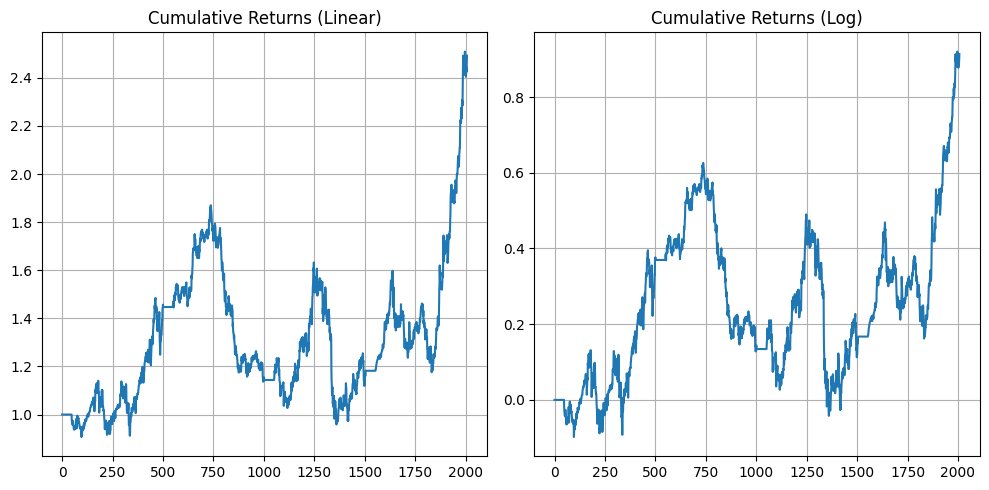

In [21]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(model_metrics["Cumulative Returns"], label="DLS")
plt.title("Cumulative Returns (Linear)")
plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(np.log(model_metrics["Cumulative Returns"]), label="DLS")
plt.title("Cumulative Returns (Log)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [22]:
print("\nModel Performance Metrics (DLS):")
for k, v in model_metrics.items():
    if k != "Cumulative Returns":
        print(f"{k}: {v:.4f}")


Model Performance Metrics (DLS):
Annualized Return (E[R]): 0.1410
Annualized Std Dev (Std[R]): 0.2293
Sharpe Ratio: 0.6150
Downside Deviation: 0.1767
Sortino Ratio: 0.7982
Max Drawdown (MDD): -0.4874
% Positive Returns: 0.4945
Avg P / Avg L: 0.9253
